In [1]:
import pandas as pd
from sympy.ntheory import digits

from email_outreach.experiment_utils.metric_loader import load_experiment_metrics
from email_outreach.ml.shallow_autoencoder.abstract_contextual_model import AbstractContextualModel
from email_outreach.utils.constants import ROOT_FOLDER
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
sns.set_style("white")
sns.set_context("paper")

In [3]:
def get_precisions_recalls(path: Path, quantiles=1 - np.linspace(start=0, stop=1, num=100)):
    experiments: list[list] = load_experiment_metrics(path)
    recalls: list[float] = []
    precisions: list[float] = []
    for experiment in experiments:
        recall, precision = AbstractContextualModel.calculate_recall_precision_at_quantiles(experiment,
                                                                                            quantiles=quantiles)[1:3]

        recalls.append(recall)
        precisions.append(precision)

    return recalls, precisions

In [4]:
def get_recalls_auc(path: Path):
    experiments: list[list] = load_experiment_metrics(path)
    recalls_auc: list[float] = []
    for experiment in experiments:
        recall_auc = AbstractContextualModel.calculate_partial_auc(experiment)
        recalls_auc.append(recall_auc)

    return recalls_auc

In [5]:
def report_recalls(recalls: list[np.ndarray], idx = (5,15,25,35), round = 3):
    mean = np.array(recalls).mean(axis=0)[list(idx)]
    std = np.array(recalls).std(axis=0)[list(idx)]
    print(f"{np.round(mean, round)} +- {np.round(std, round)}")

In [6]:
def report_recalls_auc(recalls_auc: list[float], round: int = 3):
    mean = np.array(recalls_auc).mean()
    std = np.array(recalls_auc).std()
    print(f"{np.round(mean, round)} +- {np.round(std, round)}")

In [7]:
def delta_pct(lhs: np.ndarray, rhs: np.ndarray, decimals: int = 2 ) -> np.ndarray:
    return ((lhs-rhs)*100).round(decimals)

In [8]:
baseline_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "baseline_v2"
geometric_alpha_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "geometric_alpha_v2"
lin_alpha_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "linear_alpha_v2"
adaptive_alpha_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "adaptive_alpha_v2"
exp_template_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "exp_template_v2"
non_naive_f_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "non_naive_f_v2"
revised_s_a_b_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "revised_s_a_b_v2"
revised_s_revised_f_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "revised_s_revised_f_v2"
p_var_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "p_var_v2"
cutoff_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "cutoff_v3"
deep_autoencoder_path:Path= ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "deep_autoencoder_noisy_v3"
btto_sae_exp_path: Path = ROOT_FOLDER / "experiments" / "test_set" / "1" / "contextual_bandit" / "btto_sae_exp_v3"

In [9]:
baseline_recalls, baseline_precisions = get_precisions_recalls(baseline_path)
geometric_alpha_recalls, geometric_alpha_precisions = get_precisions_recalls(geometric_alpha_path)
lin_alpha_recalls, lin_alpha_precisions = get_precisions_recalls(lin_alpha_path)
adaptive_alpha_recalls, adaptive_alpha_precisions = get_precisions_recalls(adaptive_alpha_path)
exp_template_recalls, exp_template_precisions = get_precisions_recalls(exp_template_path)
non_naive_f_recalls, non_naive_f_precisions = get_precisions_recalls(non_naive_f_path)
revised_s_a_b_recalls, revised_s_a_b_precisions = get_precisions_recalls(revised_s_a_b_path)
revised_s_revised_f_recalls, revised_s_revised_f_precisions = get_precisions_recalls(revised_s_revised_f_path)
p_var_recalls, p_var_precisions = get_precisions_recalls(p_var_path)
cutoff_recalls, cutoff_precisions = get_precisions_recalls(cutoff_path)
deep_autoencoder_recalls, deep_autoencoder_precisions = get_precisions_recalls(deep_autoencoder_path)
btto_sae_exp_recalls, btto_sae_exp_precisions = get_precisions_recalls(btto_sae_exp_path)

In [10]:
baseline_recalls_auc = get_recalls_auc(baseline_path)
geometric_alpha_recalls_auc = get_recalls_auc(geometric_alpha_path)
lin_alpha_recalls_auc = get_recalls_auc(lin_alpha_path)
adaptive_alpha_recalls_auc = get_recalls_auc(adaptive_alpha_path)
exp_template_recalls_auc = get_recalls_auc(exp_template_path)
non_naive_f_recalls_auc = get_recalls_auc(non_naive_f_path)
revised_s_a_b_recalls_auc = get_recalls_auc(revised_s_a_b_path)
revised_s_revised_f_recalls_auc = get_recalls_auc(revised_s_revised_f_path)
p_var_recalls_auc = get_recalls_auc(p_var_path)
cutoff_recalls_auc = get_recalls_auc(cutoff_path)
deep_autoencoder_recalls_auc = get_recalls_auc(deep_autoencoder_path)
btto_sae_exp_recalls_auc = get_recalls_auc(btto_sae_exp_path)

### All

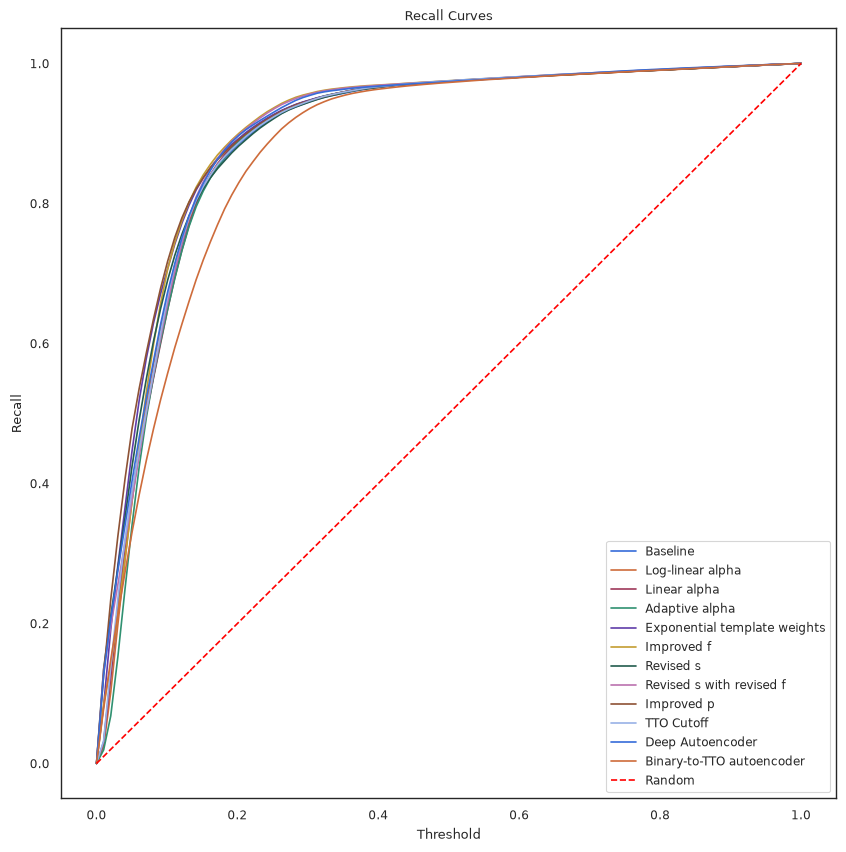

In [11]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(geometric_alpha_recalls).mean(axis=0),
         label="Log-linear alpha")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(lin_alpha_recalls).mean(axis=0), label="Linear alpha")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(adaptive_alpha_recalls).mean(axis=0),
         label="Adaptive alpha")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(exp_template_recalls).mean(axis=0),
         label="Exponential template weights")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(non_naive_f_recalls).mean(axis=0), label="Improved f")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(revised_s_a_b_recalls).mean(axis=0),
         label="Revised s")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(revised_s_revised_f_recalls).mean(axis=0),
         label="Revised s with revised f")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(p_var_recalls).mean(axis=0), label="Improved p")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(cutoff_recalls).mean(axis=0), label="TTO Cutoff")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(deep_autoencoder_recalls).mean(axis=0), label="Deep Autoencoder")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(btto_sae_exp_recalls).mean(axis=0), label="Binary-to-TTO autoencoder")


plt.plot([0,1], [0,1], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

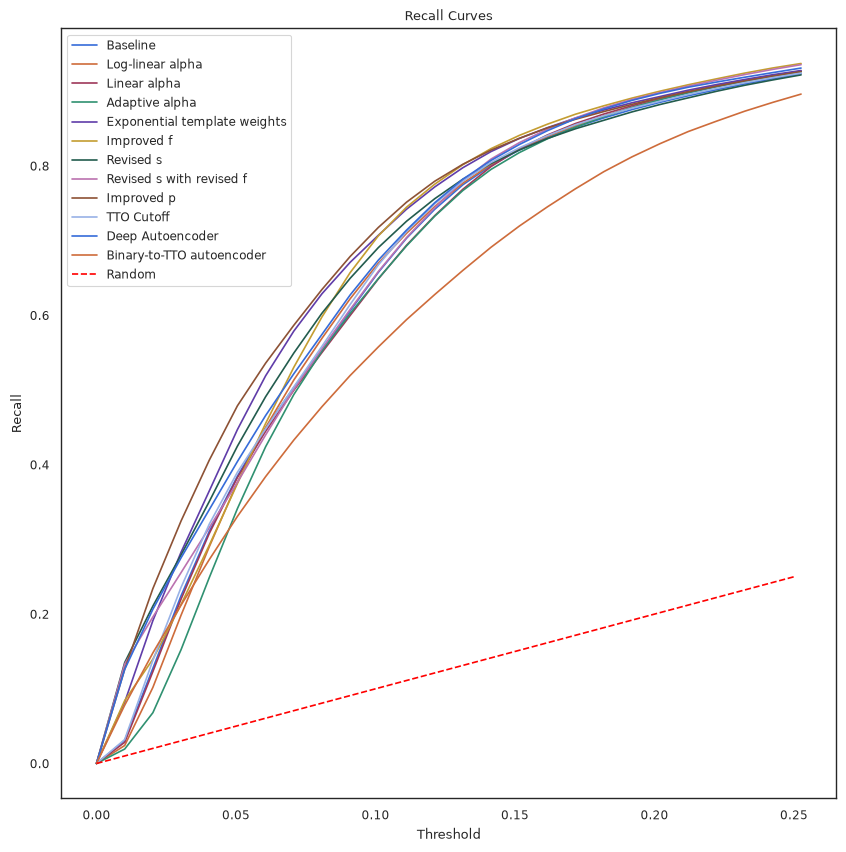

In [12]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(baseline_recalls).mean(axis=0)[:26], label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(geometric_alpha_recalls).mean(axis=0)[:26],
         label="Log-linear alpha")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(lin_alpha_recalls).mean(axis=0)[:26], label="Linear alpha")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(adaptive_alpha_recalls).mean(axis=0)[:26],
         label="Adaptive alpha")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(exp_template_recalls).mean(axis=0)[:26],
         label="Exponential template weights")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(non_naive_f_recalls).mean(axis=0)[:26], label="Improved f")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(revised_s_a_b_recalls).mean(axis=0)[:26],
         label="Revised s")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(revised_s_revised_f_recalls).mean(axis=0)[:26],
         label="Revised s with revised f")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(p_var_recalls).mean(axis=0)[:26], label="Improved p")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(cutoff_recalls).mean(axis=0)[:26], label="TTO Cutoff")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(deep_autoencoder_recalls).mean(axis=0)[:26], label="Deep Autoencoder")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(btto_sae_exp_recalls).mean(axis=0)[:26], label="Binary-to-TTO autoencoder")

plt.plot([0,0.25], [0,0.25], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

### Baseline vs Log-Linear alpha

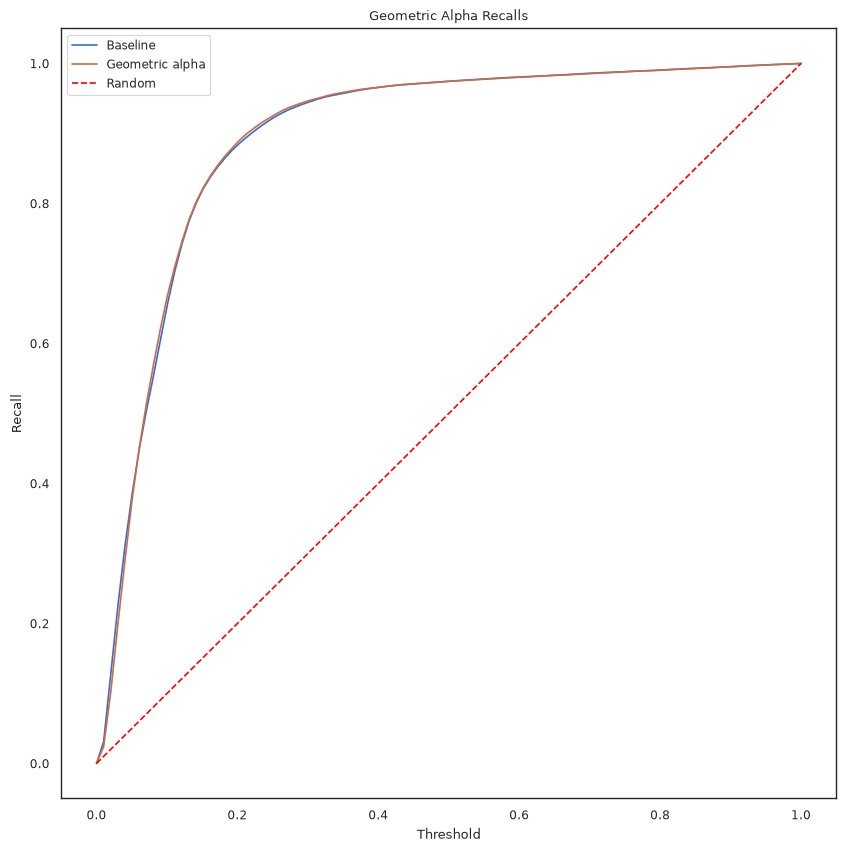

In [13]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(geometric_alpha_recalls).mean(axis=0),
         label="Geometric alpha")

plt.plot([0,1], [0,1], label="Random", color = "red", linestyle = "--")
plt.title("Geometric Alpha Recalls")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
# plt.show()

plt.savefig("images/geometric_alpha_recalls_0_1.png", bbox_inches="tight")

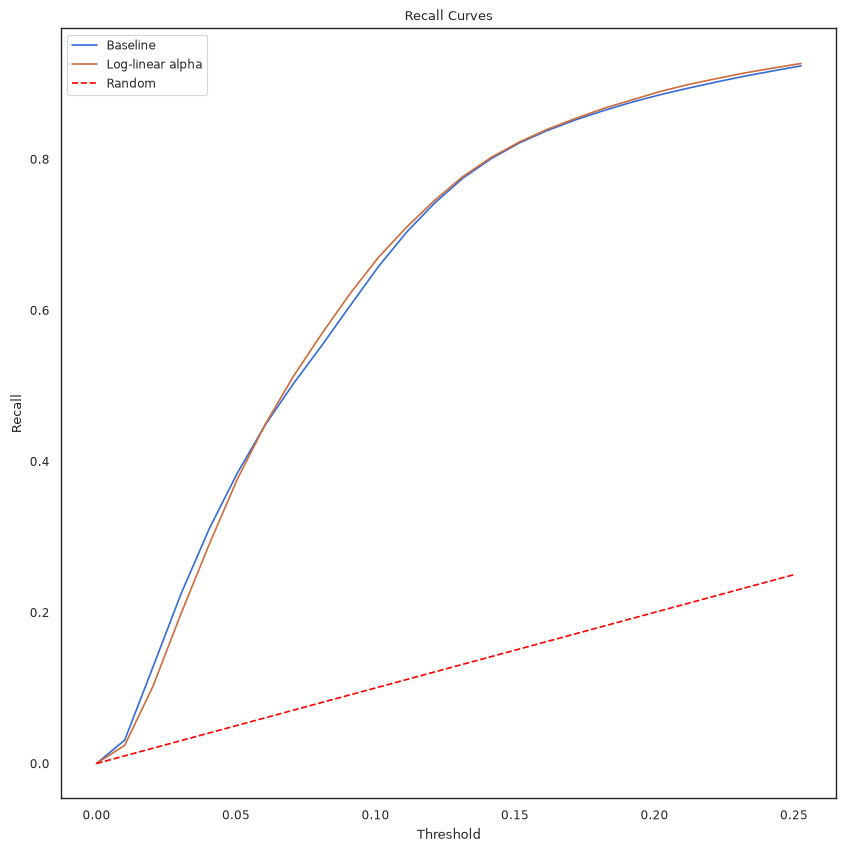

In [14]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(baseline_recalls).mean(axis=0)[:26], label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(geometric_alpha_recalls).mean(axis=0)[:26],
         label="Log-linear alpha")

plt.plot([0,0.25], [0,0.25], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

In [15]:
delta_pct(
    lhs = np.array(geometric_alpha_recalls).mean(axis=0),
    rhs = np.array(baseline_recalls).mean(axis=0),
    decimals=1
)

array([ 0. , -0.7, -2.6, -2.6, -2.1, -0.8,  0.1,  1. ,  1.6,  1.6,  1.2,
        0.7,  0.4,  0.2,  0.2,  0.1,  0.2,  0.2,  0.3,  0.3,  0.4,  0.5,
        0.4,  0.4,  0.4,  0.3,  0.3,  0.3,  0.3,  0.2,  0.2,  0.1,  0.1,
        0.1,  0.1,  0.1,  0.1,  0.1,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. , -0. , -0. , -0. , -0. , -0. , -0. ,
       -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. ,
       -0. , -0. , -0. , -0.1, -0. , -0. , -0. , -0. , -0. , -0. ,  0. ,
       -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. ,
        0. ,  0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. ,
        0. ])

In [16]:
report_recalls(geometric_alpha_recalls)

[0.377 0.823 0.927 0.959] +- [0.05  0.017 0.012 0.01 ]


In [17]:
report_recalls_auc(geometric_alpha_recalls_auc)

0.894 +- 0.009


### Baseline

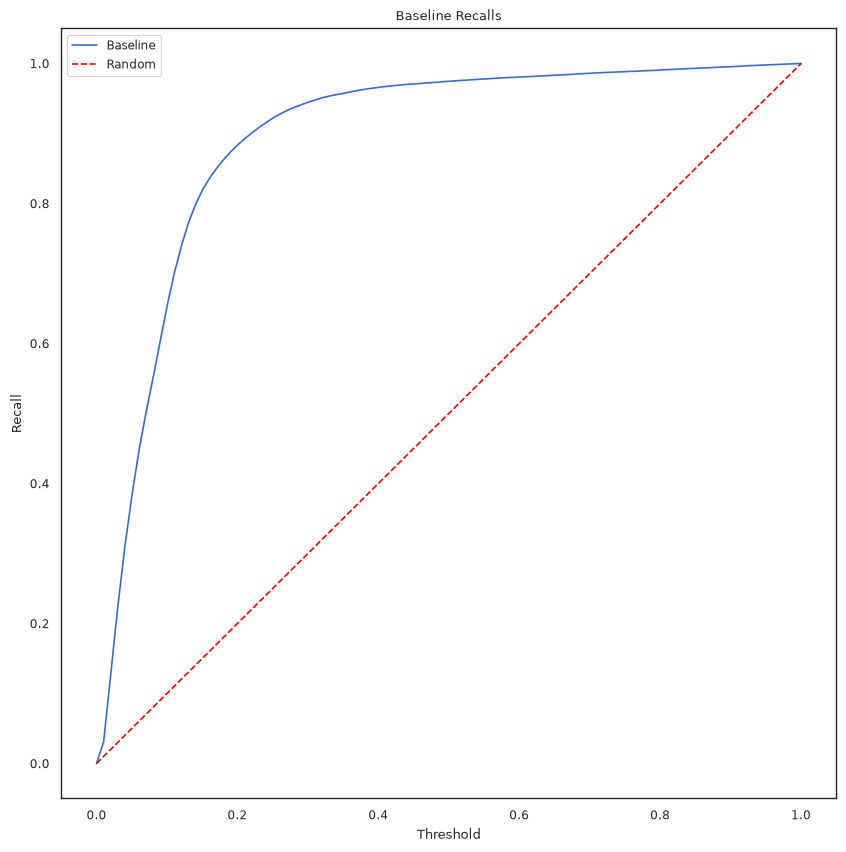

In [18]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline")

plt.plot([0,1], [0,1], label="Random", color = "red", linestyle = "--")

plt.title("Baseline Recalls")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
# plt.show()

plt.savefig("images/baseline_recalls_0_1.png", bbox_inches="tight")

In [19]:
report_recalls(baseline_recalls, (25,50,75))

[0.923 0.975 0.989] +- [0.014 0.008 0.004]


In [20]:
report_recalls(baseline_recalls)

[0.385 0.821 0.923 0.958] +- [0.076 0.028 0.014 0.011]


In [21]:
report_recalls_auc(baseline_recalls_auc)

0.894 +- 0.012


### Baseline vs Linear alpha

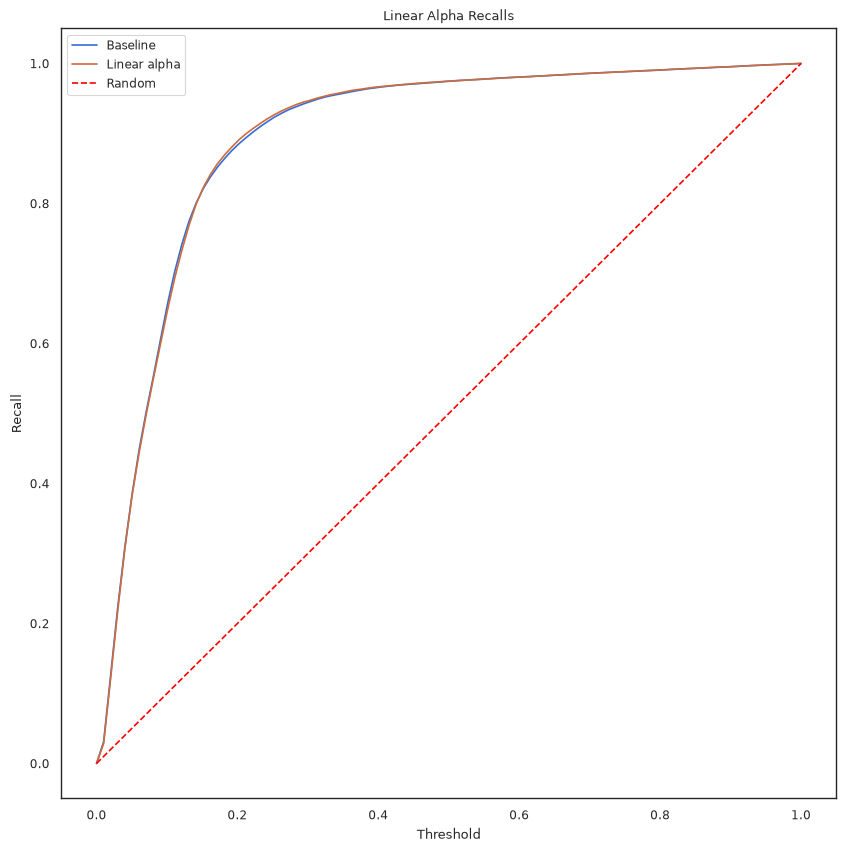

In [22]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(lin_alpha_recalls).mean(axis=0),
         label="Linear alpha")

plt.plot([0,1], [0,1], label="Random", color = "red", linestyle = "--")

plt.title("Linear Alpha Recalls")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
# plt.show()

plt.savefig("images/linear_alpha_recalls_0_1.png", bbox_inches="tight")

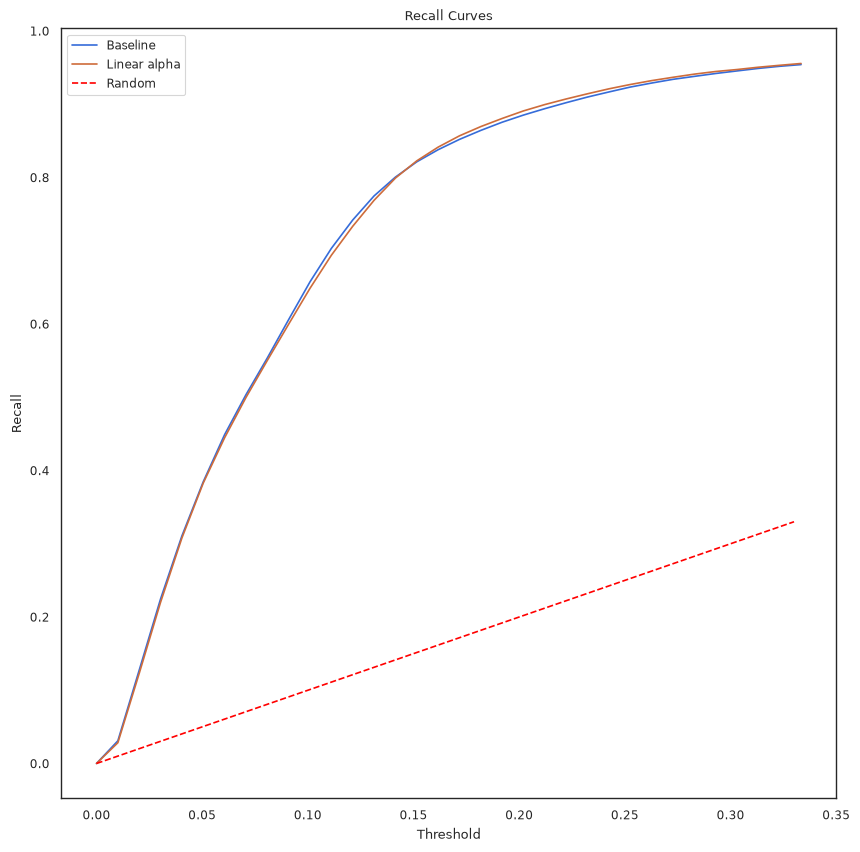

In [23]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100)[:34], np.array(baseline_recalls).mean(axis=0)[:34], label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100)[:34], np.array(lin_alpha_recalls).mean(axis=0)[:34],
         label="Linear alpha")

plt.plot([0,0.33], [0,0.33], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

In [24]:
delta_pct(
    lhs = np.array(lin_alpha_recalls).mean(axis=0),
    rhs = np.array(baseline_recalls).mean(axis=0),
    decimals=1
)

array([ 0. , -0.3, -0.4, -0.5, -0.3, -0.2, -0.4, -0.4, -0.3, -0.6, -0.9,
       -0.9, -0.9, -0.6, -0.1,  0.1,  0.4,  0.5,  0.5,  0.5,  0.6,  0.6,
        0.5,  0.4,  0.4,  0.4,  0.3,  0.3,  0.3,  0.3,  0.2,  0.2,  0.1,
        0.2,  0.2,  0.2,  0.2,  0.1,  0.1,  0.1,  0.1,  0. ,  0. ,  0. ,
        0. ,  0.1,  0.1,  0. ,  0. ,  0. ,  0. ,  0. , -0. , -0. , -0. ,
       -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. , -0. , -0. , -0. , -0. , -0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. , -0. , -0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. ,  0. ,
        0. ])

In [25]:
report_recalls(lin_alpha_recalls)

[0.383 0.823 0.927 0.96 ] +- [0.073 0.023 0.012 0.01 ]


In [26]:
report_recalls_auc(lin_alpha_recalls_auc)

0.894 +- 0.011


### Baseline vs Adaptive alpha

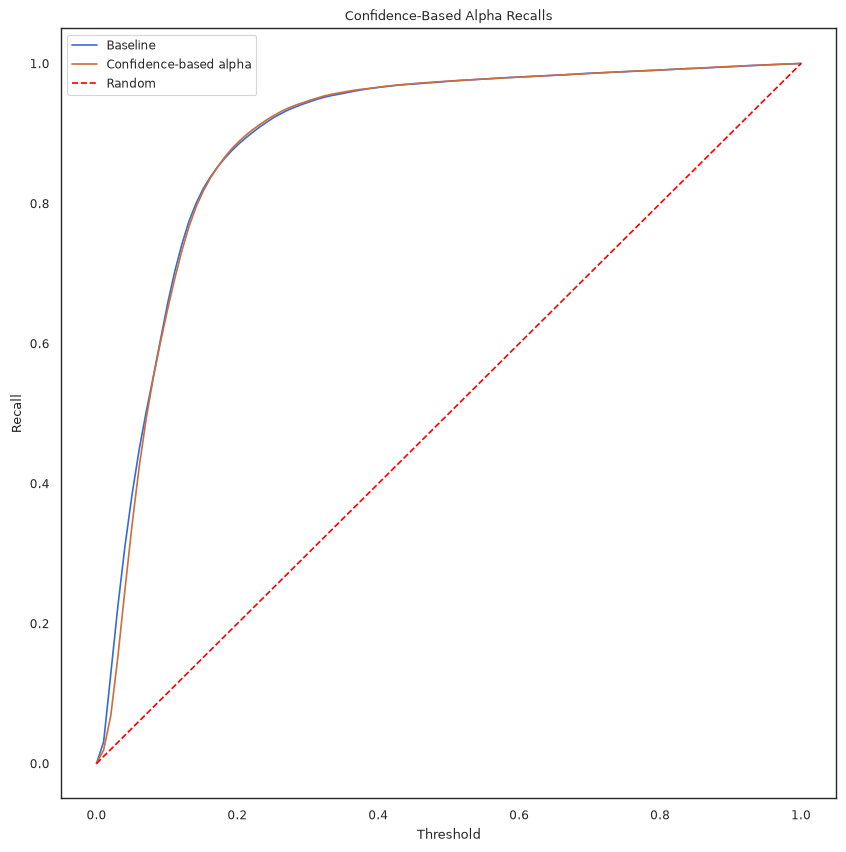

In [27]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(adaptive_alpha_recalls).mean(axis=0),
         label="Confidence-based alpha")

plt.plot([0,1], [0,1], label="Random", color = "red", linestyle = "--")

plt.title("Confidence-Based Alpha Recalls")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend(loc="upper left")
# plt.show()
plt.savefig("images/confidence_based_alpha_recalls_0_1.png", bbox_inches="tight")
# plt.savefig("images/confidence_based_alpha_recalls_0_1.png")

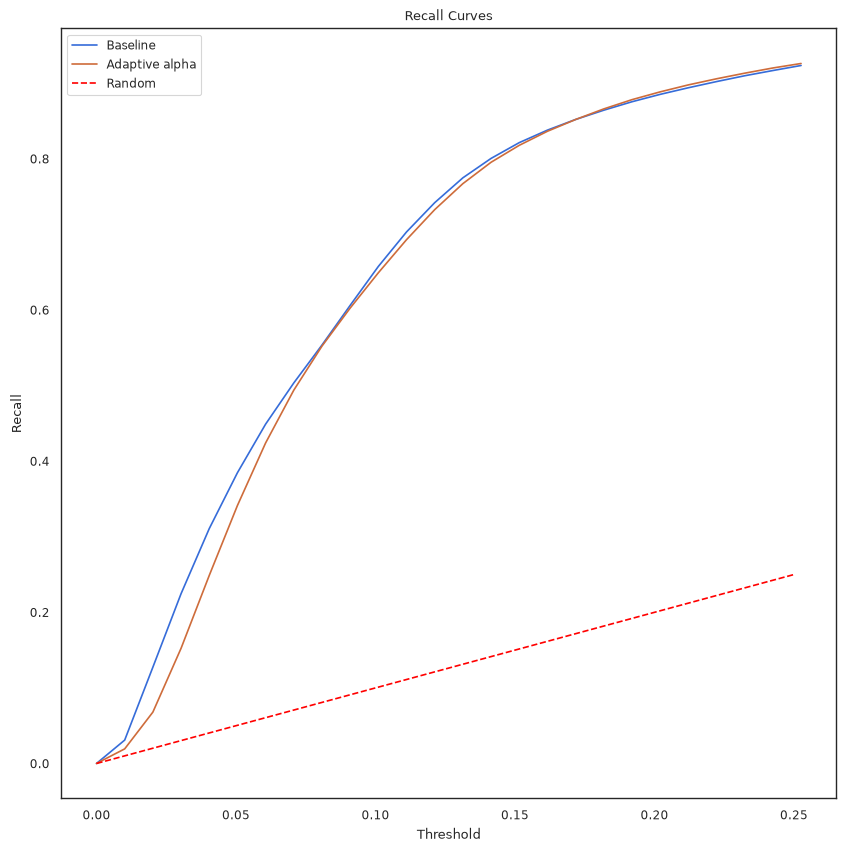

In [28]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(baseline_recalls).mean(axis=0)[:26], label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(adaptive_alpha_recalls).mean(axis=0)[:26],
         label="Adaptive alpha")

plt.plot([0,0.25], [0,0.25], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

In [29]:
delta_pct(
    lhs = np.array(adaptive_alpha_recalls).mean(axis=0),
    rhs = np.array(baseline_recalls).mean(axis=0),
    decimals=1
)

array([ 0. , -1.2, -5.9, -7.2, -6.2, -4.3, -2.5, -1. , -0.1, -0.4, -0.8,
       -1. , -0.9, -0.8, -0.5, -0.4, -0.2, -0. ,  0.2,  0.3,  0.3,  0.4,
        0.4,  0.3,  0.3,  0.3,  0.3,  0.3,  0.3,  0.2,  0.2,  0.2,  0.2,
        0.2,  0.2,  0.2,  0.1,  0.1,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0.1,  0.1,  0. ,  0.1,  0. ,  0. ,  0. ,  0. ,  0. , -0. ,
       -0. , -0. , -0. , -0. , -0. ,  0. ,  0. , -0. , -0. , -0. , -0. ,
       -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. , -0. ,  0. , -0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. , -0. ,  0. ,  0. ,  0. ,  0. ,
        0. ])

In [30]:
report_recalls(adaptive_alpha_recalls)

[0.341 0.818 0.926 0.96 ] +- [0.031 0.022 0.014 0.01 ]


In [31]:
report_recalls_auc(adaptive_alpha_recalls_auc)

0.891 +- 0.009


### Baseline vs Exponential template weights

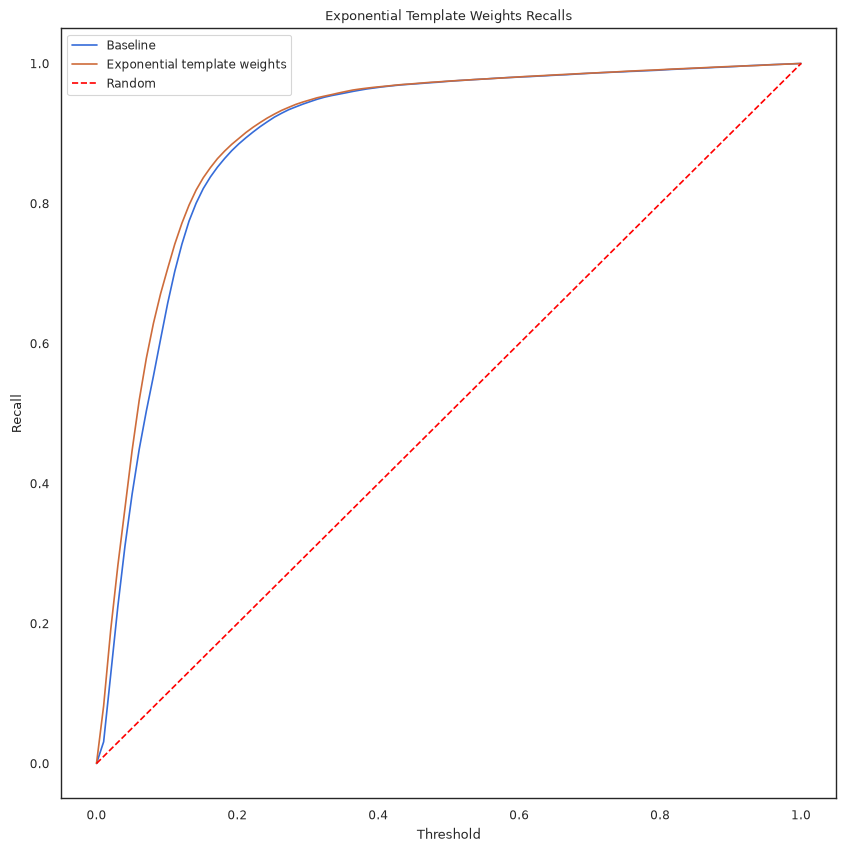

In [32]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(exp_template_recalls).mean(axis=0),
         label="Exponential template weights")

plt.plot([0,1], [0,1], label="Random", color = "red", linestyle = "--")

plt.title("Exponential Template Weights Recalls")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
# plt.show()

plt.savefig("images/exp_template_weight_recalls_0_1.png", bbox_inches="tight")

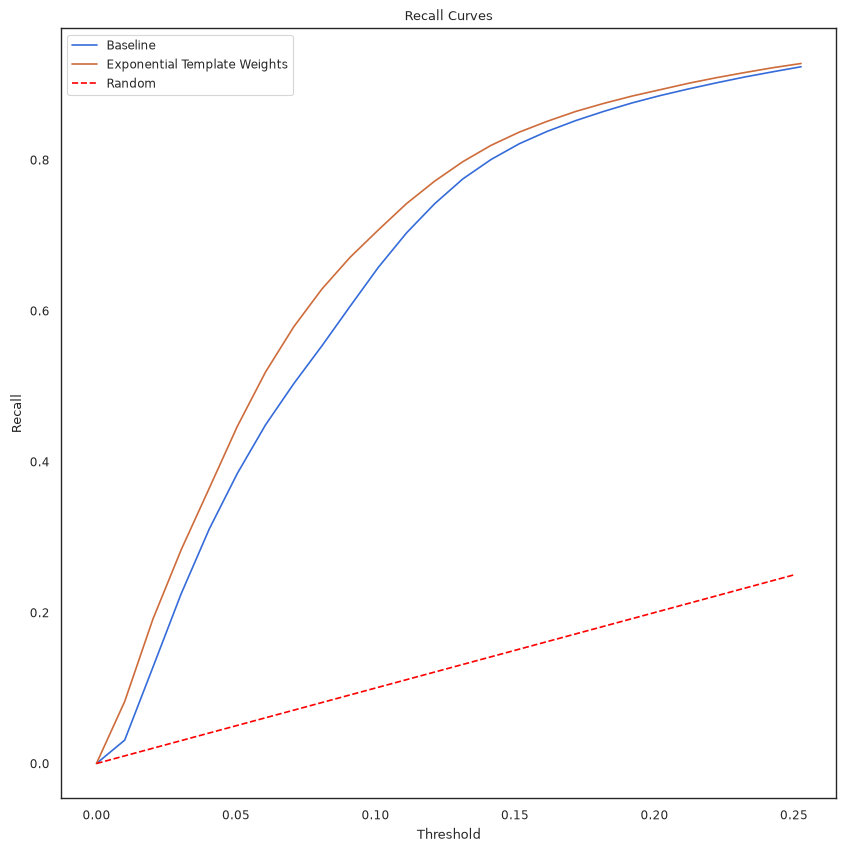

In [33]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(baseline_recalls).mean(axis=0)[:26], label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(exp_template_recalls).mean(axis=0)[:26],
         label="Exponential Template Weights")

plt.plot([0,0.25], [0,0.25], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

In [34]:
delta_pct(
    lhs = np.array(exp_template_recalls).mean(axis=0),
    rhs = np.array(baseline_recalls).mean(axis=0),
    decimals=1
)

array([ 0. ,  5.1,  6.4,  5.8,  5.4,  6.2,  7. ,  7.5,  7.5,  6.5,  5. ,
        3.9,  3. ,  2.3,  1.9,  1.5,  1.3,  1.2,  1.1,  0.9,  0.8,  0.7,
        0.7,  0.6,  0.5,  0.4,  0.4,  0.3,  0.4,  0.3,  0.3,  0.2,  0.2,
        0.1,  0.2,  0.2,  0.2,  0.2,  0.1,  0.1,  0.1,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
       -0. , -0. , -0. , -0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0.1,  0. ,  0.1,
        0.1,  0.1,  0.1,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. ,
        0. ])

In [35]:
report_recalls(exp_template_recalls)

[0.447 0.837 0.928 0.96 ] +- [0.041 0.018 0.014 0.011]


In [36]:
report_recalls_auc(exp_template_recalls_auc)

0.903 +- 0.009


### Baseline vs Improved f

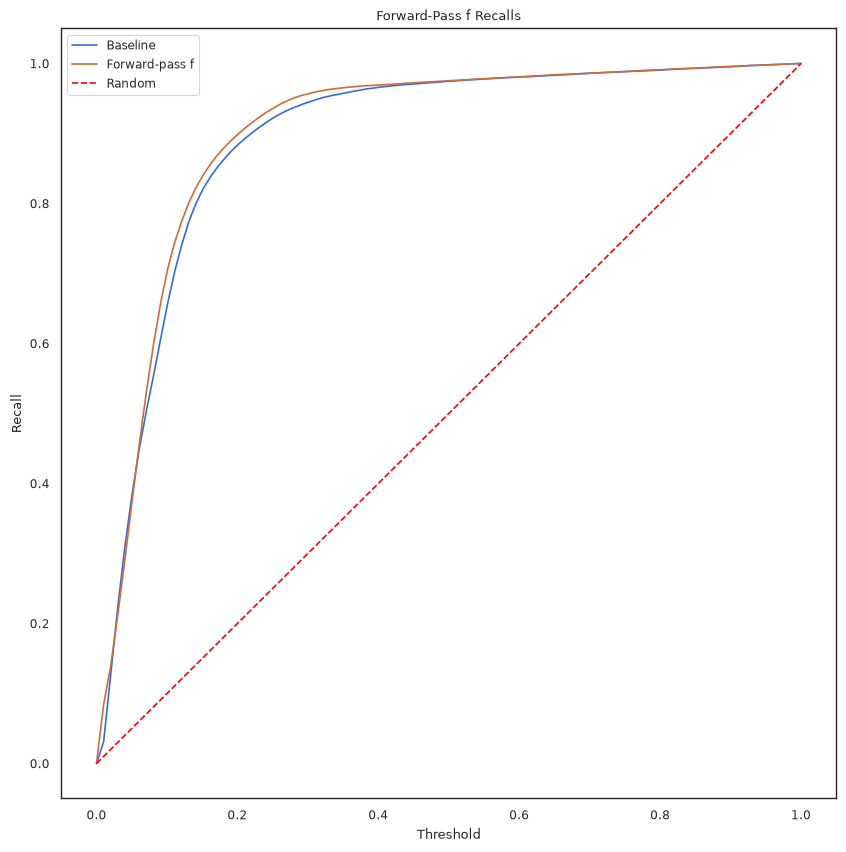

In [37]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(non_naive_f_recalls).mean(axis=0),
         label="Forward-pass f")

plt.plot([0,1], [0,1], label="Random", color = "red", linestyle = "--")

plt.title("Forward-Pass f Recalls")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
# plt.show()

plt.savefig("images/forward_pass_f_recalls_0_1.png", bbox_inches="tight")

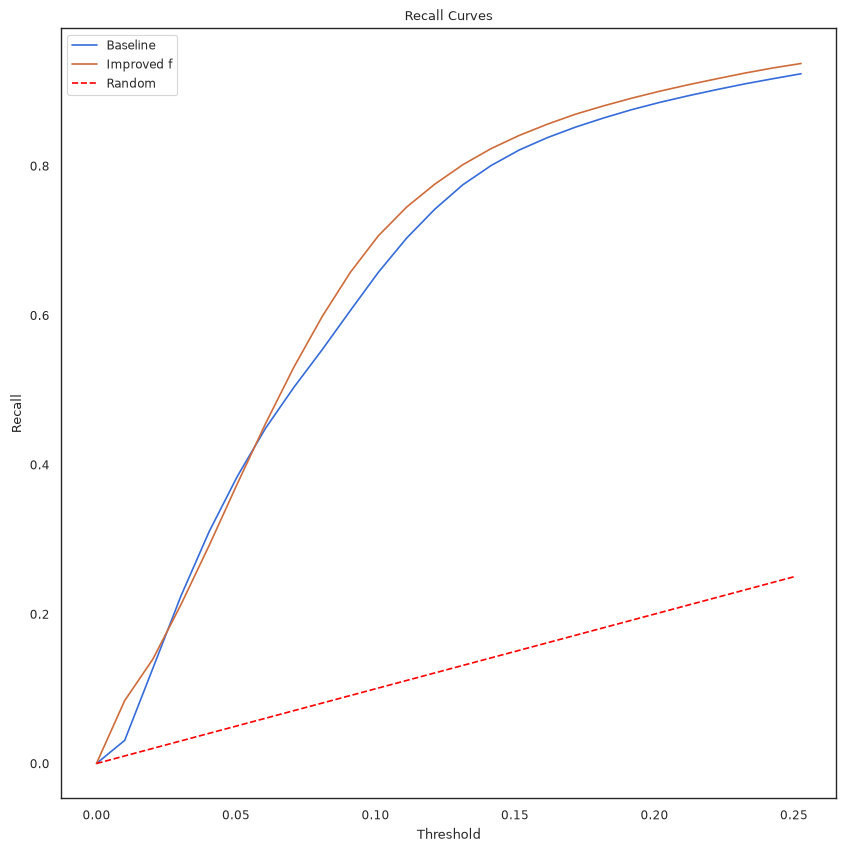

In [38]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(baseline_recalls).mean(axis=0)[:26], label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(non_naive_f_recalls).mean(axis=0)[:26],
         label="Improved f")

plt.plot([0,0.25], [0,0.25], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

In [39]:
delta_pct(
    lhs = np.array(non_naive_f_recalls).mean(axis=0),
    rhs = np.array(baseline_recalls).mean(axis=0),
    decimals=1
)

array([ 0. ,  5.3,  1.2, -1.2, -1.9, -1. ,  0.6,  2.7,  4.4,  5.1,  4.9,
        4.2,  3.4,  2.7,  2.3,  1.9,  1.8,  1.7,  1.6,  1.5,  1.5,  1.5,
        1.4,  1.4,  1.4,  1.4,  1.4,  1.4,  1.4,  1.3,  1.2,  1.1,  1. ,
        0.9,  0.8,  0.8,  0.7,  0.6,  0.5,  0.4,  0.3,  0.2,  0.2,  0.2,
        0.2,  0.2,  0.1,  0.1,  0.1,  0.1,  0.1,  0. ,  0.1,  0.1,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0.1,  0.1,  0.1,
        0. ,  0. ,  0. ,  0. ,  0. , -0. ,  0. ,  0. ,  0. ,  0. ,  0.1,
        0.1,  0.1,  0.1,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. , -0. , -0. ,  0. ,  0. ,  0. ,
        0. ])

In [40]:
report_recalls(non_naive_f_recalls)

[0.375 0.841 0.937 0.966] +- [0.049 0.029 0.018 0.01 ]


In [41]:
report_recalls_auc(non_naive_f_recalls_auc)

0.901 +- 0.011


### Baseline vs Revised s

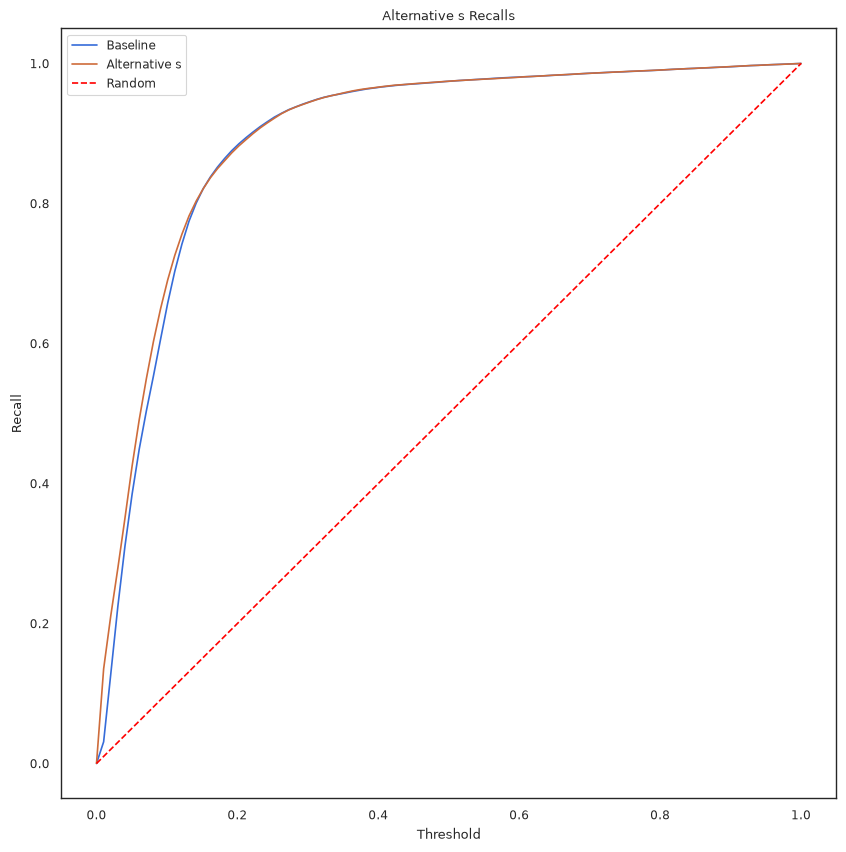

In [42]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(revised_s_a_b_recalls).mean(axis=0),
         label="Alternative s")

plt.plot([0,1], [0,1], label="Random", color = "red", linestyle = "--")

plt.title("Alternative s Recalls")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
# plt.show()

plt.savefig("images/alternative_s_recalls_0_1.png", bbox_inches="tight")

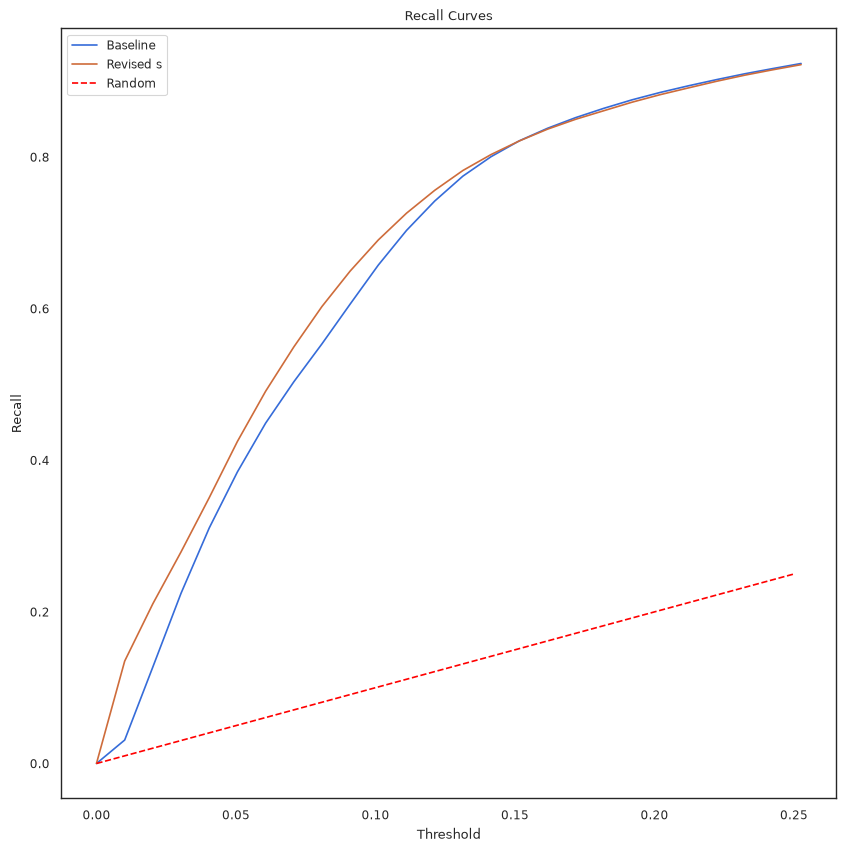

In [43]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(baseline_recalls).mean(axis=0)[:26], label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(revised_s_a_b_recalls).mean(axis=0)[:26],
         label="Revised s")

plt.plot([0,0.25], [0,0.25], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

In [44]:
delta_pct(
    lhs = np.array(revised_s_a_b_recalls).mean(axis=0),
    rhs = np.array(baseline_recalls).mean(axis=0),
    decimals=1
)

array([ 0. , 10.4,  8.3,  5.5,  4. ,  4. ,  4.2,  4.6,  4.9,  4.4,  3.3,
        2.3,  1.4,  0.7,  0.3, -0. , -0.1, -0.2, -0.3, -0.3, -0.3, -0.3,
       -0.2, -0.2, -0.2, -0.2, -0.1, -0. , -0. , -0. , -0. , -0. , -0. ,
       -0. ,  0. ,  0.1,  0.1,  0.1,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. , -0. , -0. , -0. , -0. ,
       -0. , -0. , -0. , -0. , -0. , -0. ,  0. , -0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. , -0. , -0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. , -0. , -0. ,  0. , -0. ,  0. ,  0. ,  0. , -0. ,
        0. ,  0. ,  0. , -0. ,  0. , -0. , -0. , -0. , -0. , -0. , -0. ,
        0. ])

In [45]:
report_recalls(revised_s_a_b_recalls)

[0.425 0.821 0.922 0.959] +- [0.026 0.017 0.013 0.01 ]


In [46]:
report_recalls_auc(revised_s_a_b_recalls_auc)

0.9 +- 0.008


### Baseline vs Revised s with revised f

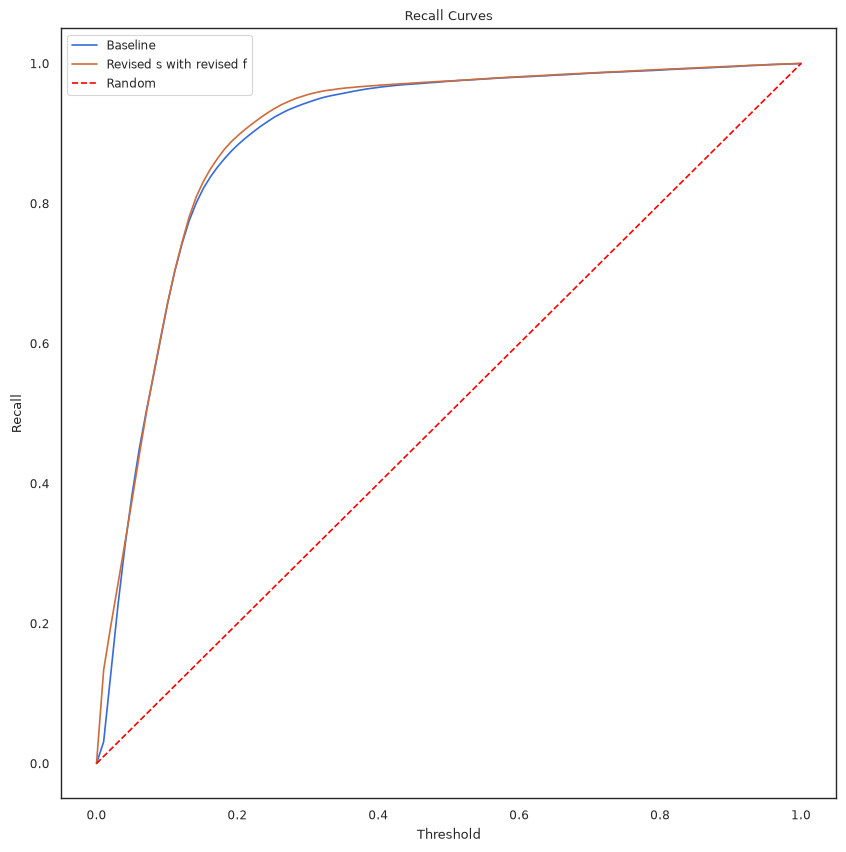

In [47]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(revised_s_revised_f_recalls).mean(axis=0),
         label="Revised s with revised f")



plt.plot([0,1], [0,1], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

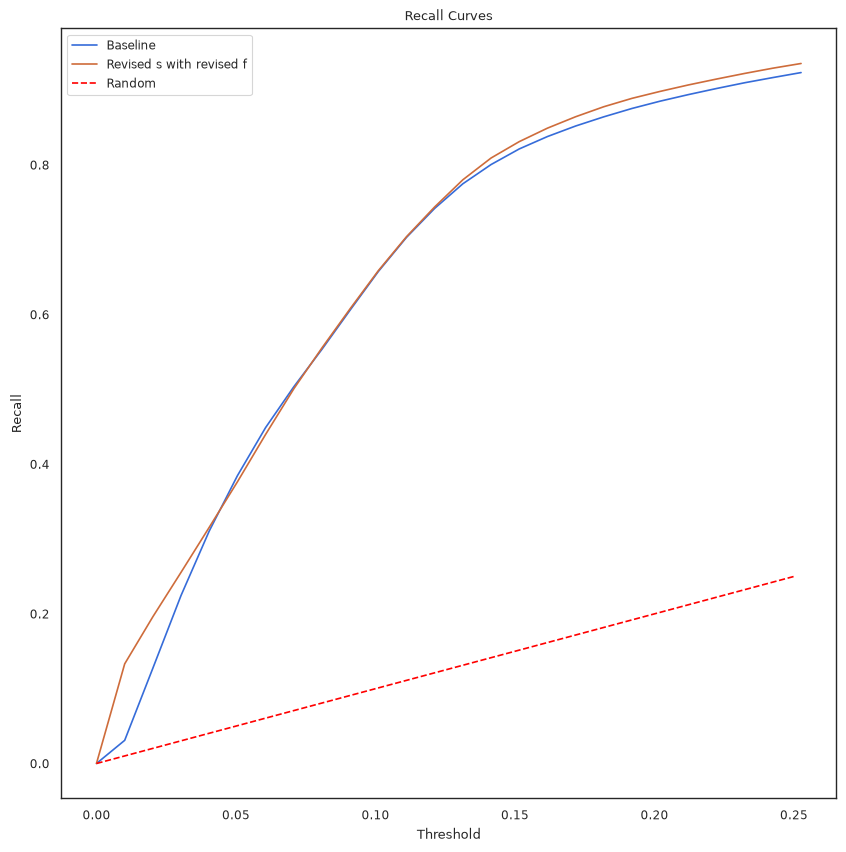

In [48]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(baseline_recalls).mean(axis=0)[:26], label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(revised_s_revised_f_recalls).mean(axis=0)[:26],
         label="Revised s with revised f")

plt.plot([0,0.25], [0,0.25], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

In [49]:
delta_pct(
    lhs = np.array(revised_s_revised_f_recalls).mean(axis=0),
    rhs = np.array(baseline_recalls).mean(axis=0),
    decimals=1
)

array([ 0. , 10.2,  6.9,  3.1,  0.5, -0.8, -0.9, -0.3,  0.2,  0.2,  0.1,
        0.1,  0.2,  0.5,  0.9,  1. ,  1.1,  1.2,  1.4,  1.4,  1.3,  1.3,
        1.3,  1.2,  1.3,  1.2,  1.2,  1.2,  1.2,  1.1,  1.1,  1. ,  0.9,
        0.8,  0.8,  0.7,  0.6,  0.5,  0.4,  0.3,  0.3,  0.2,  0.2,  0.1,
        0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,
        0.1,  0.1,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0.1,  0.1,  0.1,
        0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0. ,  0.1,  0.1,  0.1,  0.1,
        0.1,  0.1,  0.1,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ])

### Baseline vs Improved p

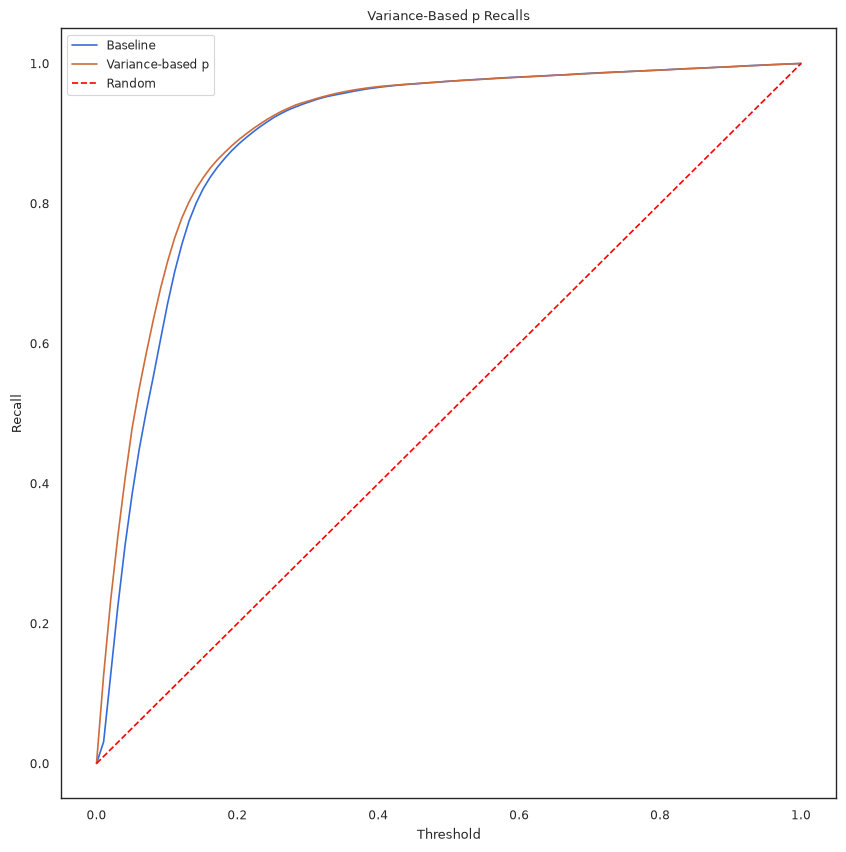

In [50]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(p_var_recalls).mean(axis=0),
         label="Variance-based p")

plt.plot([0,1], [0,1], label="Random", color = "red", linestyle = "--")

plt.title("Variance-Based p Recalls")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()

plt.savefig("images/variance_based_p_recalls_0_1.png", bbox_inches="tight")
# plt.show()

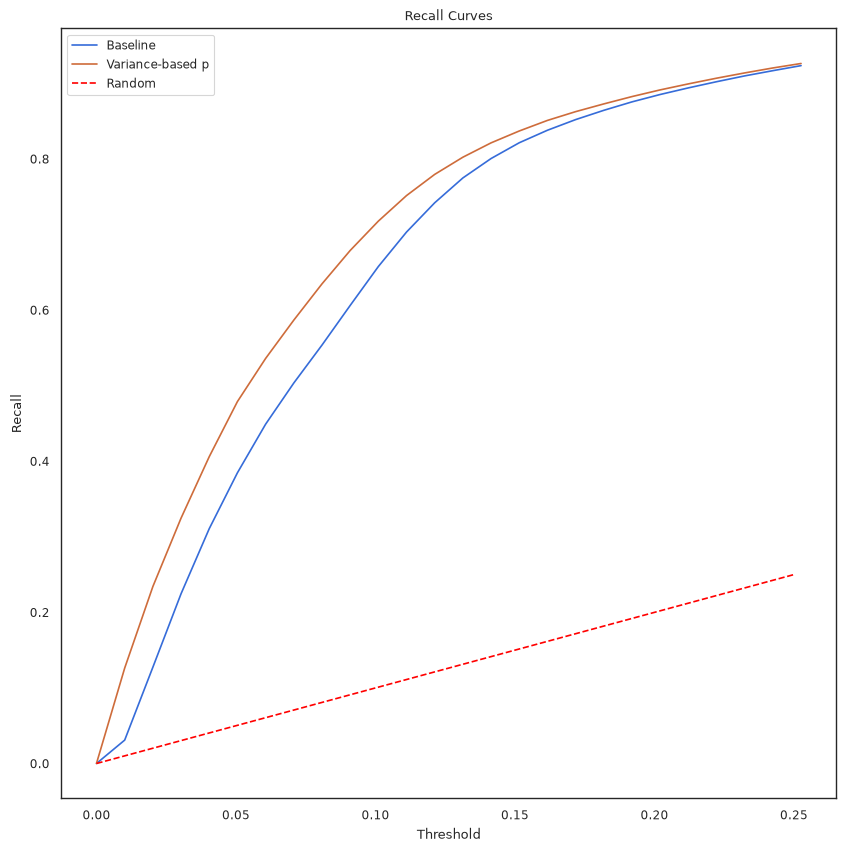

In [51]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(baseline_recalls).mean(axis=0)[:26], label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(p_var_recalls).mean(axis=0)[:26],
         label="Variance-based p")

plt.plot([0,0.25], [0,0.25], label="Random", color = "red", linestyle = "--")

plt.title("Recall Curves")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()
plt.show()

In [52]:
delta_pct(
    lhs = np.array(p_var_recalls).mean(axis=0),
    rhs = np.array(baseline_recalls).mean(axis=0),
    decimals=1
)

array([ 0. ,  9.5, 10.7, 10. ,  9.5,  9.4,  8.7,  8.3,  8.1,  7.3,  6. ,
        4.8,  3.8,  2.7,  2.1,  1.6,  1.3,  1.1,  0.8,  0.7,  0.6,  0.5,
        0.5,  0.4,  0.4,  0.3,  0.3,  0.2,  0.3,  0.2,  0.2,  0.1,  0.1,
        0.1,  0.2,  0.2,  0.2,  0.2,  0.1,  0.1,  0.1,  0.1,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. , -0. , -0. , -0. , -0. , -0. ,
       -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. ,
       -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. , -0. ,  0. ,
        0. ,  0. ,  0. , -0. , -0. , -0. , -0. , -0. , -0. ,  0. , -0. ,
        0. ,  0. , -0. , -0. , -0. , -0. , -0. , -0. ,  0. ,  0. , -0. ,
        0. ])

In [53]:
report_recalls(p_var_recalls)

[0.479 0.837 0.926 0.96 ] +- [0.034 0.017 0.013 0.01 ]


In [54]:
report_recalls_auc(p_var_recalls_auc)

0.905 +- 0.009


### Binary-to-TTO Autoencoder

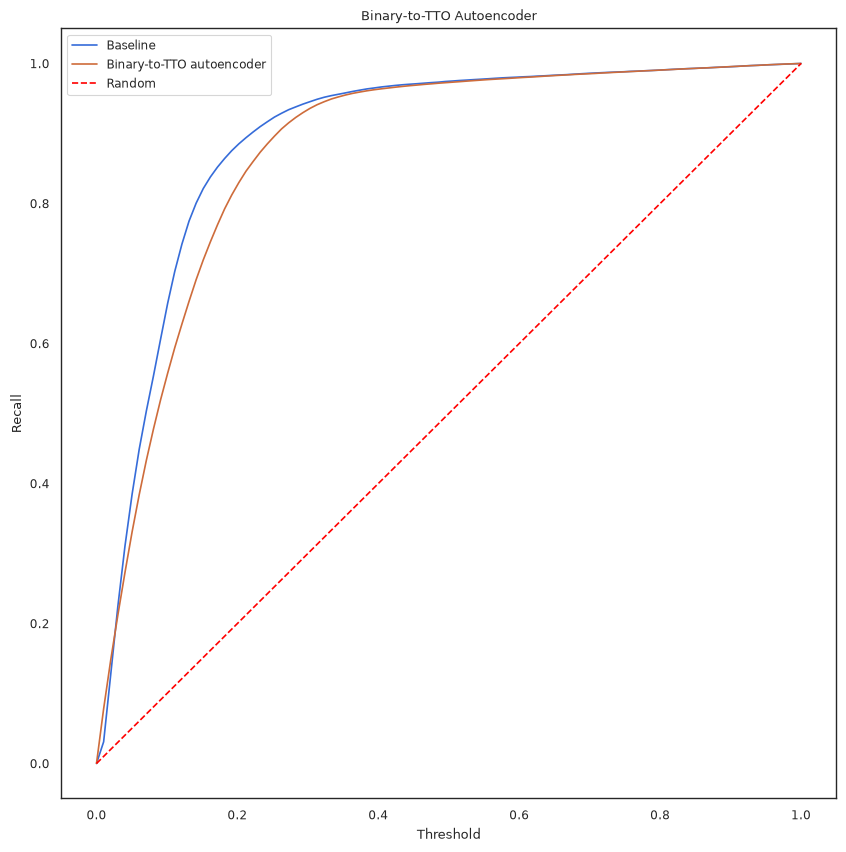

In [55]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(btto_sae_exp_recalls).mean(axis=0),
         label="Binary-to-TTO autoencoder")

plt.plot([0,1], [0,1], label="Random", color = "red", linestyle = "--")

plt.title("Binary-to-TTO Autoencoder")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()

plt.savefig("images/binary_to_tto_autoencoder_recalls_0_1.png", bbox_inches="tight")
# plt.show()

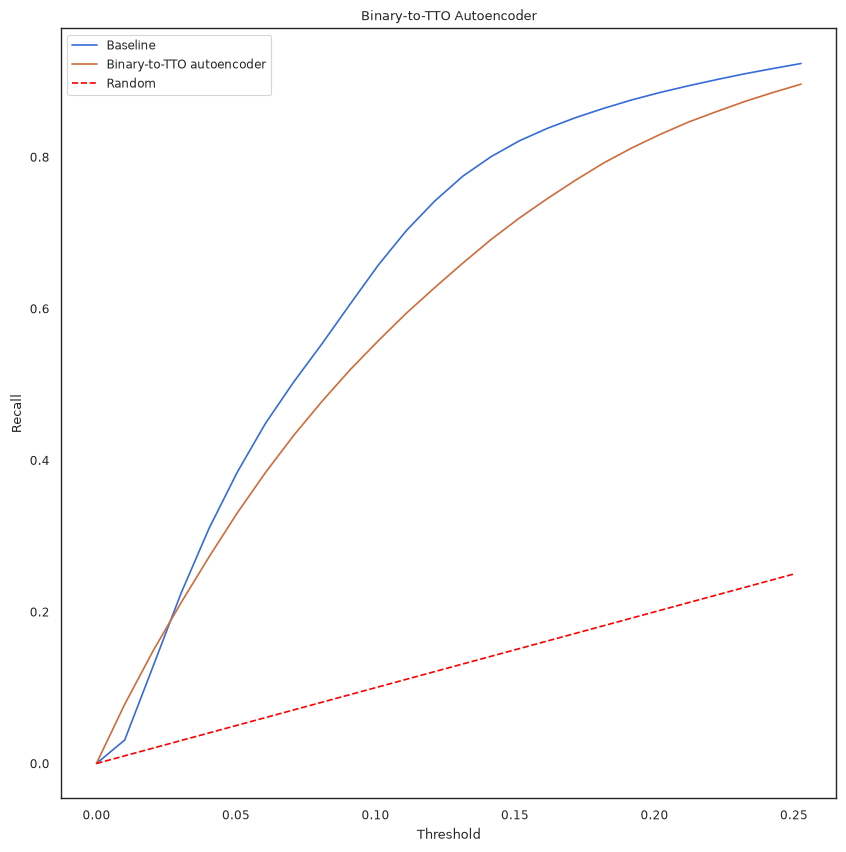

In [56]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(baseline_recalls).mean(axis=0)[:26], label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100)[:26], np.array(btto_sae_exp_recalls).mean(axis=0)[:26],
         label="Binary-to-TTO autoencoder")

plt.plot([0,0.25], [0,0.25], label="Random", color = "red", linestyle = "--")

plt.title("Binary-to-TTO Autoencoder")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()

# plt.savefig("images/binary_to_tto_autoencoder_recalls_0_1.png", bbox_inches="tight")
plt.show()

In [57]:
delta_pct(
    lhs = np.array(btto_sae_exp_recalls).mean(axis=0),
    rhs = np.array(baseline_recalls).mean(axis=0),
    decimals=1
)

array([  0. ,   4.7,   2.1,  -1.3,  -3.8,  -5.4,  -6.5,  -7. ,  -7.6,
        -8.7, -10. , -10.9, -11.4, -11.5, -10.9, -10.2,  -9.3,  -8.2,
        -7.2,  -6.3,  -5.5,  -4.8,  -4.2,  -3.7,  -3.2,  -2.7,  -2.2,
        -1.9,  -1.5,  -1.2,  -1. ,  -0.8,  -0.6,  -0.5,  -0.4,  -0.3,
        -0.3,  -0.3,  -0.3,  -0.3,  -0.3,  -0.3,  -0.2,  -0.2,  -0.2,
        -0.2,  -0.2,  -0.2,  -0.1,  -0.2,  -0.2,  -0.2,  -0.1,  -0.1,
        -0.1,  -0.1,  -0.1,  -0.1,  -0.1,  -0.1,  -0.1,  -0.1,  -0.1,
        -0.1,  -0.1,  -0. ,  -0. ,  -0. ,  -0. ,  -0.1,  -0.1,  -0. ,
        -0. ,  -0. ,  -0. ,  -0. ,  -0. ,  -0. ,  -0. ,   0. ,  -0. ,
        -0. ,  -0. ,  -0. ,  -0. ,  -0. ,  -0. ,  -0. ,   0. ,   0. ,
         0. ,  -0. ,  -0. ,  -0. ,   0. ,   0. ,   0. ,   0. ,   0. ,
         0. ])

In [58]:
report_recalls(btto_sae_exp_recalls)

[0.331 0.719 0.896 0.955] +- [0.051 0.04  0.015 0.008]


In [59]:
report_recalls_auc(btto_sae_exp_recalls_auc)

0.877 +- 0.011


### Baseline vs TTO Cutoff

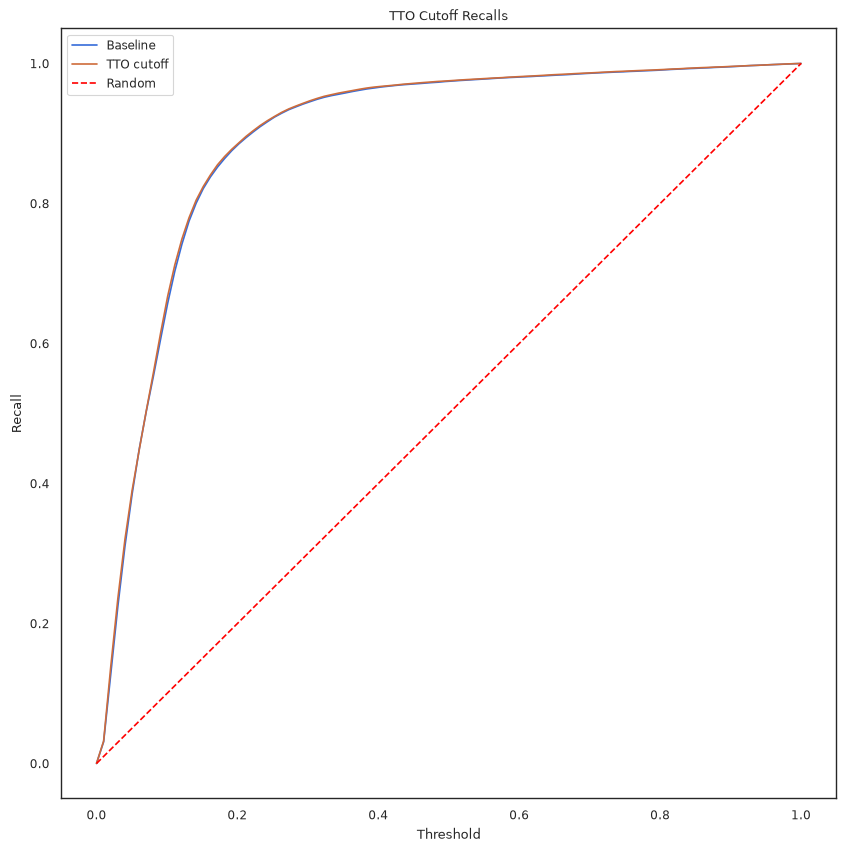

In [60]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(cutoff_recalls).mean(axis=0),
         label="TTO cutoff")

plt.plot([0,1], [0,1], label="Random", color = "red", linestyle = "--")

plt.title("TTO Cutoff Recalls")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()

plt.savefig("images/tto_cutoff_recalls_0_1.png", bbox_inches="tight")
# plt.show()

In [61]:
delta_pct(
    lhs = np.array(cutoff_recalls).mean(axis=0),
    rhs = np.array(baseline_recalls).mean(axis=0),
    decimals=1
)

array([ 0. ,  0.1,  1.1,  1.1,  1. ,  0.5, -0.1,  0.1,  0.5,  0.9,  1. ,
        0.9,  0.7,  0.5,  0.4,  0.3,  0.3,  0.3,  0.3,  0.2,  0.1,  0.2,
        0.2,  0.2,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,
        0.1,  0.2,  0.2,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,
        0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,
        0.1,  0. ,  0. ,  0. ,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,
        0.1,  0.1,  0.1,  0.1,  0. ,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,
        0.1,  0.1,  0.1,  0. ,  0. ,  0. ,  0. ,  0.1,  0.1,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0. , -0. ,  0. ,  0. ,  0. ,  0. ,
        0. ])

In [62]:
report_recalls(cutoff_recalls)

[0.39  0.824 0.924 0.96 ] +- [0.038 0.016 0.012 0.01 ]


In [63]:
report_recalls_auc(cutoff_recalls_auc)

0.895 +- 0.008


### Baseline vs Deep Autoencoder

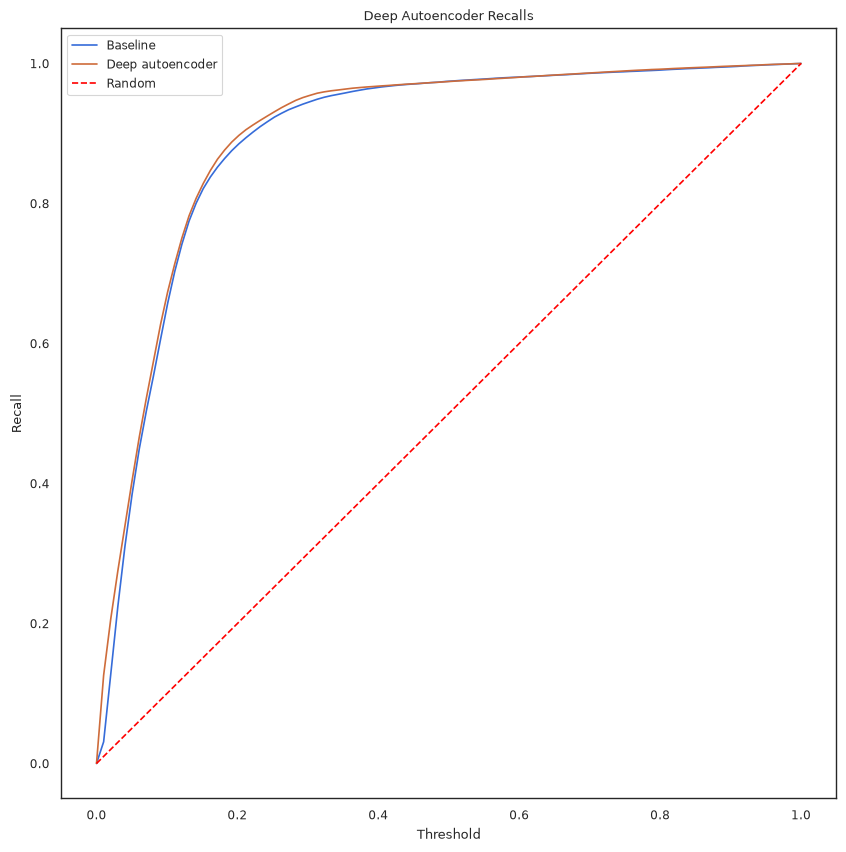

In [64]:
plt.figure(figsize=(10, 10))

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(baseline_recalls).mean(axis=0), label="Baseline")

plt.plot(np.linspace(start=0, stop=1, num=100), np.array(deep_autoencoder_recalls).mean(axis=0),
         label="Deep autoencoder")

plt.plot([0,1], [0,1], label="Random", color = "red", linestyle = "--")

plt.title("Deep Autoencoder Recalls")
plt.xlabel("Threshold")
plt.ylabel("Recall")
plt.legend()

plt.savefig("images/deep_autoencoder_recalls_0_1.png", bbox_inches="tight")
# plt.show()

In [65]:
delta_pct(
    lhs = np.array(deep_autoencoder_recalls).mean(axis=0),
    rhs = np.array(baseline_recalls).mean(axis=0),
    decimals=1
)

array([ 0. ,  9.5,  7.9,  5.1,  2.9,  2. ,  1.7,  1.8,  2.1,  2.1,  1.6,
        1.1,  0.9,  0.7,  0.7,  0.7,  0.9,  1.1,  1.2,  1.2,  1.2,  1.1,
        1. ,  0.9,  0.8,  0.8,  0.8,  0.8,  0.9,  0.9,  0.9,  0.9,  0.8,
        0.7,  0.6,  0.5,  0.5,  0.4,  0.3,  0.2,  0.2,  0.1,  0.1,  0. ,
        0. ,  0. ,  0. ,  0. , -0. , -0. , -0. , -0. , -0. , -0.1, -0.1,
       -0.1, -0.1, -0.1, -0. , -0. , -0. ,  0. , -0. ,  0. ,  0. ,  0. ,
        0. ,  0. ,  0. ,  0. ,  0. ,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,
        0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,  0.1,
        0.1,  0.1,  0.1,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
        0. ])

In [66]:
report_recalls(deep_autoencoder_recalls)

[0.404 0.829 0.931 0.963] +- [0.086 0.052 0.019 0.011]


In [67]:
report_recalls_auc(deep_autoencoder_recalls_auc)

0.9 +- 0.017
